Epochs: [    0   500  1000  1500  2000  2500  3000  3500  4000  4500  5000  5500
  6000  6500  7000  7500  8000  8500  9000  9500 10000 10500 11000 11500
 12000 12500 13000 13500 14000 14500 15000 15500 16000 16500 17000 17500
 18000 18500 19000 19500 20000 20500 21000 21500 22000 22500 23000 23500
 24000 24500 25000 25500 26000 26500 27000 27500 28000 28500 29000 29500
 30000]
Losses: [3.085256 0.611385 0.406329 0.269827 0.177638 0.157108 0.165673 0.136618
 0.185683 0.349252 0.132121 0.131183 0.120298 0.119704 0.129097 0.224559
 0.12328  0.192878 0.335181 0.240017 0.156476 0.161011 0.157851 0.150893
 0.1129   0.116553 0.129586 0.106651 0.106755 0.114923 0.125528 0.111307
 0.17757  0.114693 0.10682  0.119066 0.155372 0.165633 0.192907 0.136019
 0.118445 0.428826 0.396454 0.379006 0.364832 0.35262  0.341606 0.331237
 0.320965 0.310534 0.299644 0.288123 0.27709  0.267762 0.257258 0.24812
 0.239758 0.231359 0.222145 0.213316 0.208045]


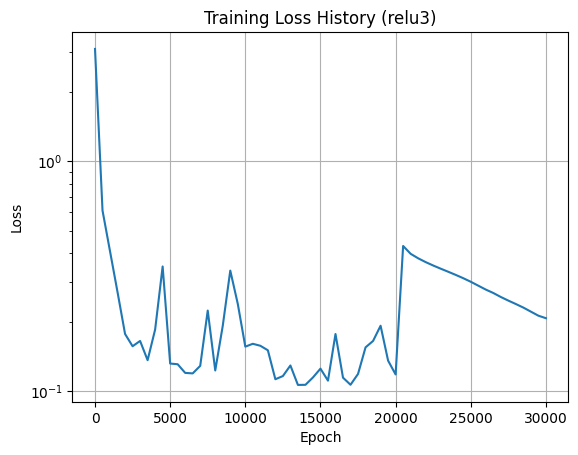

In [3]:
import re

txt_path = "colab.txt"  # 改成你的实际路径

epochs = []
losses = []

with open(txt_path, "r", encoding="utf-8") as f:
    for line in f:
        if "Epoch" in line and "Loss" in line:
            match = re.search(r"Epoch\s+(\d+):\s+Loss\s+([0-9.eE+-]+)", line)
            if match:
                epoch = int(match.group(1))
                loss = float(match.group(2))
                epochs.append(epoch)
                losses.append(loss)

import numpy as np

epochs = np.array(epochs)
losses = np.array(losses)

print("Epochs:", epochs)
print("Losses:", losses)


import matplotlib.pyplot as plt

plt.semilogy(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History (relu3)")
plt.grid(True)
plt.show()


--- Training Maxwell PINN (relu3) ---
Epoch 0: Loss 2.80639 (PDE: 0.00078, BC: 0.28056)
Epoch 500: Loss 0.35618 (PDE: 0.01993, BC: 0.03362)
Epoch 1000: Loss 0.29713 (PDE: 0.01569, BC: 0.02814)
Epoch 1500: Loss 0.26950 (PDE: 0.01349, BC: 0.02560)
Epoch 2000: Loss 0.25360 (PDE: 0.01197, BC: 0.02416)
Epoch 2500: Loss 0.24543 (PDE: 0.01312, BC: 0.02323)
Epoch 3000: Loss 0.23810 (PDE: 0.01218, BC: 0.02259)
Generating Plots...


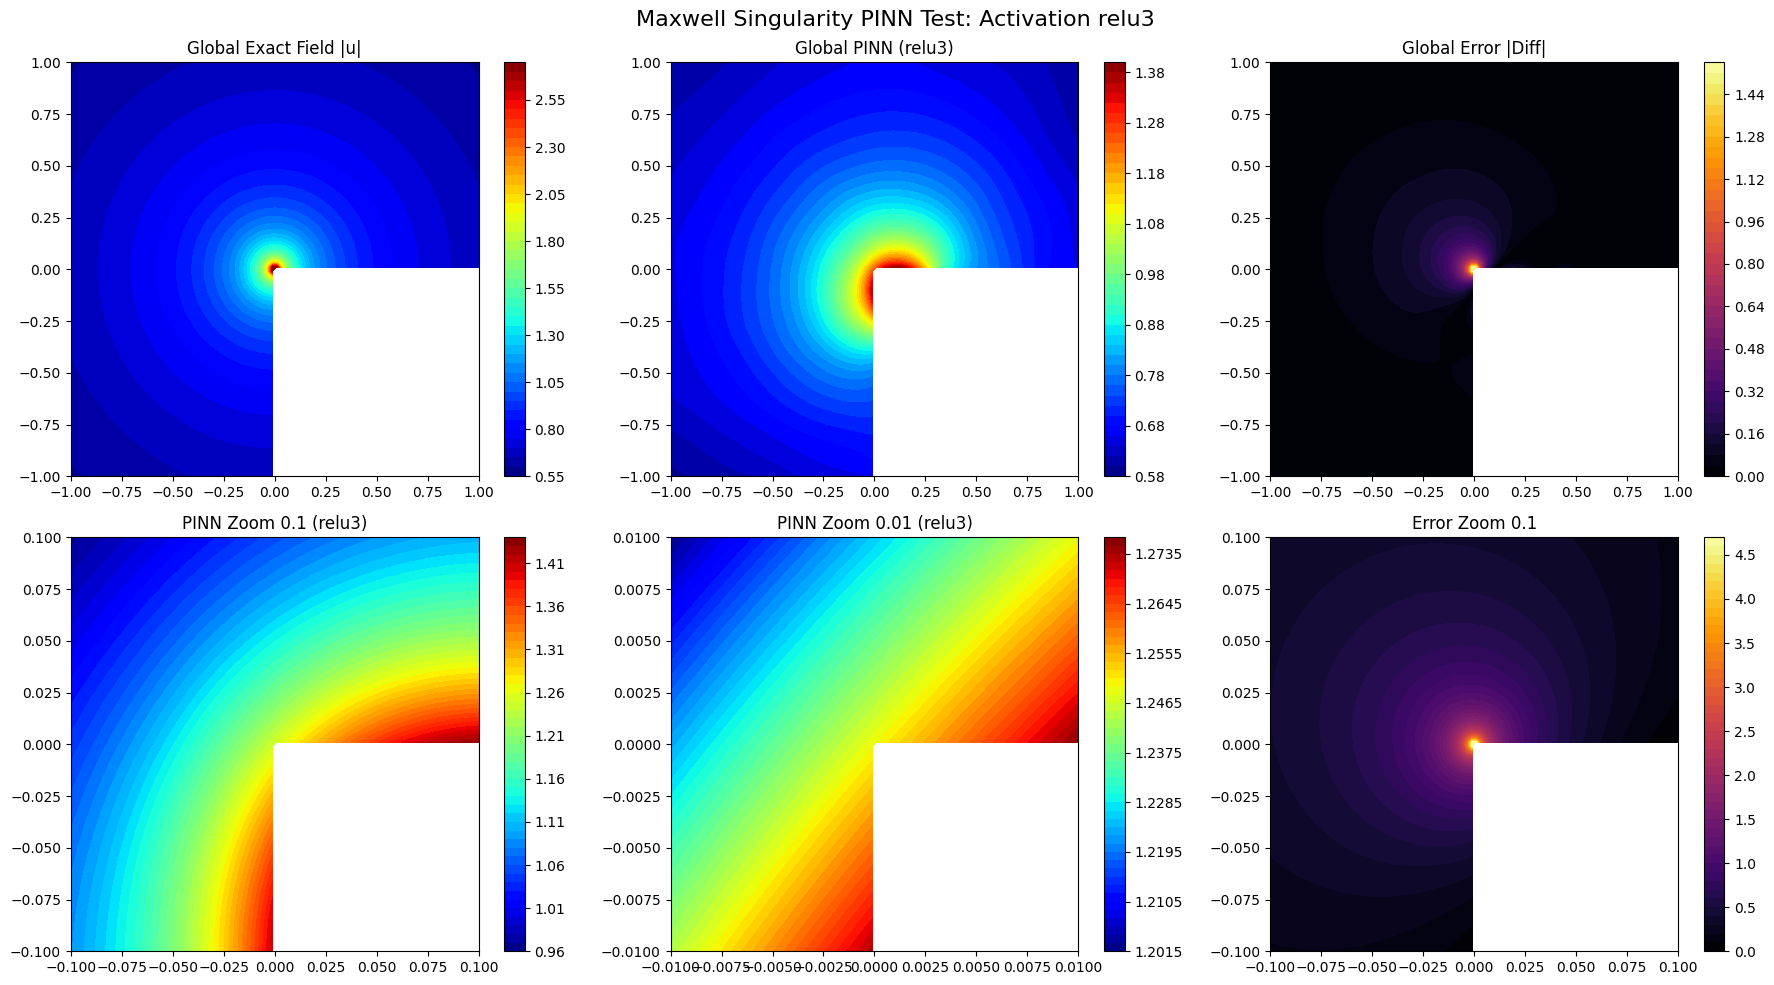

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 矢量 Maxwell 真解生成器 (Ground Truth)
# ---------------------------------------------------------
def get_maxwell_exact(x, y):
    # 转极坐标
    r = np.sqrt(x**2 + y**2) + 1e-8
    theta = np.arctan2(y, x)
    theta = np.where(theta < 0, theta + 2*np.pi, theta)
    
    alpha = 2/3.0
    
    # 标量势 Phi 的导数
    dPhi_dr = alpha * (r**(alpha - 1)) * np.sin(alpha * theta)
    dPhi_dtheta = alpha * (r**alpha) * np.cos(alpha * theta)
    
    cos_t = x / r
    sin_t = y / r
    
    dPhi_dx = cos_t * dPhi_dr - (sin_t / r) * dPhi_dtheta
    dPhi_dy = sin_t * dPhi_dr + (cos_t / r) * dPhi_dtheta
    
    u_x = dPhi_dy
    u_y = -dPhi_dx
    
    return u_x, u_y

def get_maxwell_exact_torch(x_tensor):
    x = x_tensor[:, 0:1]
    y = x_tensor[:, 1:2]
    
    r = torch.sqrt(x**2 + y**2) + 1e-6
    theta = torch.atan2(y, x)
    theta = torch.where(theta < 0, theta + 2*np.pi, theta)
    
    alpha = 2/3.0
    
    dPhi_dr = alpha * (r**(alpha - 1)) * torch.sin(alpha * theta)
    dPhi_dtheta = alpha * (r**alpha) * torch.cos(alpha * theta)
    
    cos_t = x / r
    sin_t = y / r
    
    dPhi_dx = cos_t * dPhi_dr - (sin_t / r) * dPhi_dtheta
    dPhi_dy = sin_t * dPhi_dr + (cos_t / r) * dPhi_dtheta
    
    return torch.cat([dPhi_dy, -dPhi_dx], dim=1)

# ---------------------------------------------------------
# 2. PINN 网络模型 (包含新的激活函数)
# ---------------------------------------------------------

# 定义自定义激活函数模块
class CubicReLU(nn.Module):
    def forward(self, x):
        return torch.pow(torch.relu(x), 3)

class SinAct(nn.Module):
    def forward(self, x):
        return torch.sin(x)

class VectorPINN(nn.Module):
    def __init__(self, activation_name='tanh'):
        super().__init__()
        
        # 激活函数选择逻辑
        if activation_name == 'tanh':
            self.act = nn.Tanh()
        elif activation_name == 'relu':
            self.act = nn.ReLU()
        elif activation_name == 'relu3':
            self.act = CubicReLU()
        elif activation_name == 'sin' or activation_name == 'siren':
            self.act = SinAct()
        elif activation_name == 'rational':
            self.act = None # 特殊处理
            self.act_fn = lambda x: x / (1 + torch.abs(x))
        else:
            print(f"Warning: Unknown activation '{activation_name}', using Tanh.")
            self.act = nn.Tanh()
            
        self.activation_name = activation_name
        
        # 定义层
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc_out = nn.Linear(64, 2)

    def forward(self, x):
        if self.activation_name == 'rational':
            h = self.fc1(x)
            h = self.act_fn(h)
            h = self.fc2(h)
            h = self.act_fn(h)
            h = self.fc3(h)
            h = self.act_fn(h)
            return self.fc_out(h)
        else:
            h = self.act(self.fc1(x))
            h = self.act(self.fc2(h))
            h = self.act(self.fc3(h))
            return self.fc_out(h)

# ---------------------------------------------------------
# 3. 残差计算
# ---------------------------------------------------------
def maxwell_residual(model, x_in):
    x_in.requires_grad = True
    u = model(x_in)
    u_x = u[:, 0:1]
    u_y = u[:, 1:2]
    
    # 一阶导
    d_uy_dx = torch.autograd.grad(u_y, x_in, torch.ones_like(u_y), create_graph=True)[0][:, 0:1]
    d_ux_dy = torch.autograd.grad(u_x, x_in, torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    
    scalar_curl = d_uy_dx - d_ux_dy
    
    # 二阶导 (Curl of Curl)
    d_curl_dy = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0][:, 1:2]
    d_curl_dx = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0][:, 0:1]
    
    res_x = d_curl_dy 
    res_y = -d_curl_dx
    
    # Divergence
    d_ux_dx = torch.autograd.grad(u_x, x_in, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    d_uy_dy = torch.autograd.grad(u_y, x_in, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    res_div = d_ux_dx + d_uy_dy
    
    return res_x, res_y, res_div

# ---------------------------------------------------------
# 4. 训练流程
# ---------------------------------------------------------

# 设置激活函数类型：可选 'tanh', 'relu3', 'sin'
ACT_TYPE = 'relu3' 
# ACT_TYPE = 'sin' # 如果想试 Siren

model = VectorPINN(ACT_TYPE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# L-shape 内部点生成 (Domain: [-1,1]^2, exclude x>0 & y<0)
pts = np.random.rand(5000, 2) * 2 - 1
mask = ~((pts[:, 0] > 0) & (pts[:, 1] < 0))
x_col = torch.tensor(pts[mask], dtype=torch.float32)

# 边界点生成 (L-Shape 的 6 条边)
# 1. Bottom (y=-1, x in [-1, 0]) *注意L型底部只有左半边*
n1_x = torch.rand(100,1)
x_bc1 = torch.cat([-n1_x, -torch.ones_like(n1_x)], dim=1) 

# 2. Left (x=-1, y in [-1, 1])
n2_y = torch.rand(200,1) * 2 - 1
x_bc2 = torch.cat([-torch.ones_like(n2_y), n2_y], dim=1)

# 3. Top (y=1, x in [-1, 1])
n3_x = torch.rand(200,1) * 2 - 1
x_bc3 = torch.cat([n3_x, torch.ones_like(n3_x)], dim=1)

# 4. Right (x=1, y in [0, 1]) *注意L型右侧只有上半边*
n4_y = torch.rand(100,1)
x_bc4 = torch.cat([torch.ones_like(n4_y), n4_y], dim=1)

# 5. Re-entrant Horizontal (y=0, x in [0, 1])
n5_x = torch.rand(100,1)
x_bc5 = torch.cat([n5_x, torch.zeros_like(n5_x)], dim=1)

# 6. Re-entrant Vertical (x=0, y in [-1, 0])
n6_y = torch.rand(100,1)
x_bc6 = torch.cat([torch.zeros_like(n6_y), -n6_y], dim=1)

x_bc = torch.cat([x_bc1, x_bc2, x_bc3, x_bc4, x_bc5, x_bc6], dim=0)
u_bc_true = get_maxwell_exact_torch(x_bc)

print(f"--- Training Maxwell PINN ({ACT_TYPE}) ---")

for epoch in range(3001): # 稍微减少步数以便演示，实际需更多
    optimizer.zero_grad()
    
    # PDE Loss
    rx, ry, rdiv = maxwell_residual(model, x_col)
    loss_pde = torch.mean(rx**2 + ry**2) + torch.mean(rdiv**2)
    
    # BC Loss
    u_pred_bc = model(x_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc_true)**2)
    
    loss = loss_pde + 10 * loss_bc
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f} (PDE: {loss_pde.item():.5f}, BC: {loss_bc.item():.5f})")

# ---------------------------------------------------------
# 5. 绘图与验证逻辑 (修正版)
# ---------------------------------------------------------
print("Generating Plots...")

def evaluate_grid(x_lin, y_lin, model, clip_val=50.0):
    """辅助函数：在指定网格上计算真值、预测值和误差"""
    X, Y = np.meshgrid(x_lin, y_lin)
    # L-shape 几何掩码: x>0 且 y<0 的区域为外部
    geom_mask = (X > 0) & (Y < 0)
    
    XY = np.stack([X.ravel(), Y.ravel()], 1)
    XY_torch = torch.tensor(XY, dtype=torch.float32)
    
    with torch.no_grad():
        U_vec = model(XY_torch).numpy()
        U_mag_pred = np.sqrt(U_vec[:,0]**2 + U_vec[:,1]**2).reshape(X.shape)
    
    ux_true, uy_true = get_maxwell_exact(X, Y)
    U_mag_true = np.sqrt(ux_true**2 + uy_true**2)
    
    # 截断奇异点数值以防止绘图全红
    U_mag_true_clipped = np.clip(U_mag_true, 0, clip_val)
    U_mag_pred_clipped = np.clip(U_mag_pred, 0, clip_val)
    
    # 计算误差 (使用未截断的值更准确，但绘图时截断)
    err = np.abs(U_mag_pred - U_mag_true)
    err_clipped = np.clip(err, 0, clip_val)
    
    # 应用几何掩码
    U_mag_true_clipped[geom_mask] = np.nan
    U_mag_pred_clipped[geom_mask] = np.nan
    err_clipped[geom_mask] = np.nan
    
    return X, Y, U_mag_true_clipped, U_mag_pred_clipped, err_clipped

# 定义三个不同尺度的网格
n_grid = 100
# 1. Global: [-1, 1]
x_g = np.linspace(-1, 1, n_grid)
y_g = np.linspace(-1, 1, n_grid)
res_global = evaluate_grid(x_g, y_g, model)

# 2. Medium Zoom: [-0.1, 0.1]
x_m = np.linspace(-0.1, 0.1, n_grid)
y_m = np.linspace(-0.1, 0.1, n_grid)
res_median = evaluate_grid(x_m, y_m, model)

# 3. Micro Zoom: [-0.01, 0.01]
x_s = np.linspace(-0.01, 0.01, n_grid)
y_s = np.linspace(-0.01, 0.01, n_grid)
res_small = evaluate_grid(x_s, y_s, model)

# 绘图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: Global Views ---
X, Y, True_F, Pred_F, Err_F = res_global

# 1-1: Exact Global
im0 = axes[0, 0].contourf(X, Y, True_F, levels=50, cmap='jet')
axes[0, 0].set_title("Global Exact Field |u|")
fig.colorbar(im0, ax=axes[0, 0])

# 1-2: PINN Global
im1 = axes[0, 1].contourf(X, Y, Pred_F, levels=50, cmap='jet')
axes[0, 1].set_title(f"Global PINN ({ACT_TYPE})")
fig.colorbar(im1, ax=axes[0, 1])

# 1-3: Global Error
im2 = axes[0, 2].contourf(X, Y, Err_F, levels=50, cmap='inferno')
axes[0, 2].set_title("Global Error |Diff|")
fig.colorbar(im2, ax=axes[0, 2])

# --- Row 2: Zoom Views ---

# 2-1: PINN Zoom 0.1
X_m, Y_m, _, Pred_m, _ = res_median
im3 = axes[1, 0].contourf(X_m, Y_m, Pred_m, levels=50, cmap='jet')
axes[1, 0].set_title(f"PINN Zoom 0.1 ({ACT_TYPE})")
fig.colorbar(im3, ax=axes[1, 0])

# 2-2: PINN Zoom 0.01
X_s, Y_s, _, Pred_s, _ = res_small
im4 = axes[1, 1].contourf(X_s, Y_s, Pred_s, levels=50, cmap='jet')
axes[1, 1].set_title(f"PINN Zoom 0.01 ({ACT_TYPE})")
fig.colorbar(im4, ax=axes[1, 1])

# 2-3: Error Zoom 0.1 (Looking at accuracy near singularity)
_, _, _, _, Err_m = res_median
im5 = axes[1, 2].contourf(X_m, Y_m, Err_m, levels=50, cmap='inferno')
axes[1, 2].set_title("Error Zoom 0.1")
fig.colorbar(im5, ax=axes[1, 2])

plt.suptitle(f"Maxwell Singularity PINN Test: Activation {ACT_TYPE}", fontsize=16)
plt.tight_layout()
plt.show()


--- Training Maxwell PINN (tanh) ---
Trying to capture singularity where Field -> Infinity at (0,0)
Epoch 0: Loss 5.22178
Epoch 500: Loss 1.30512
Epoch 1000: Loss 1.27226
Epoch 1500: Loss 1.23608
Epoch 2000: Loss 1.18843
Epoch 2500: Loss 1.12998
Epoch 3000: Loss 1.05293
Epoch 3500: Loss 0.96287
Epoch 4000: Loss 0.88288
Epoch 4500: Loss 0.82462
Epoch 5000: Loss 0.77988
Epoch 5500: Loss 0.74726
Epoch 6000: Loss 0.72030
Epoch 6500: Loss 0.69765
Epoch 7000: Loss 0.67805
Epoch 7500: Loss 0.66067
Epoch 8000: Loss 0.64604
Epoch 8500: Loss 0.63446
Epoch 9000: Loss 0.62493
Epoch 9500: Loss 0.61668
Epoch 10000: Loss 0.60937


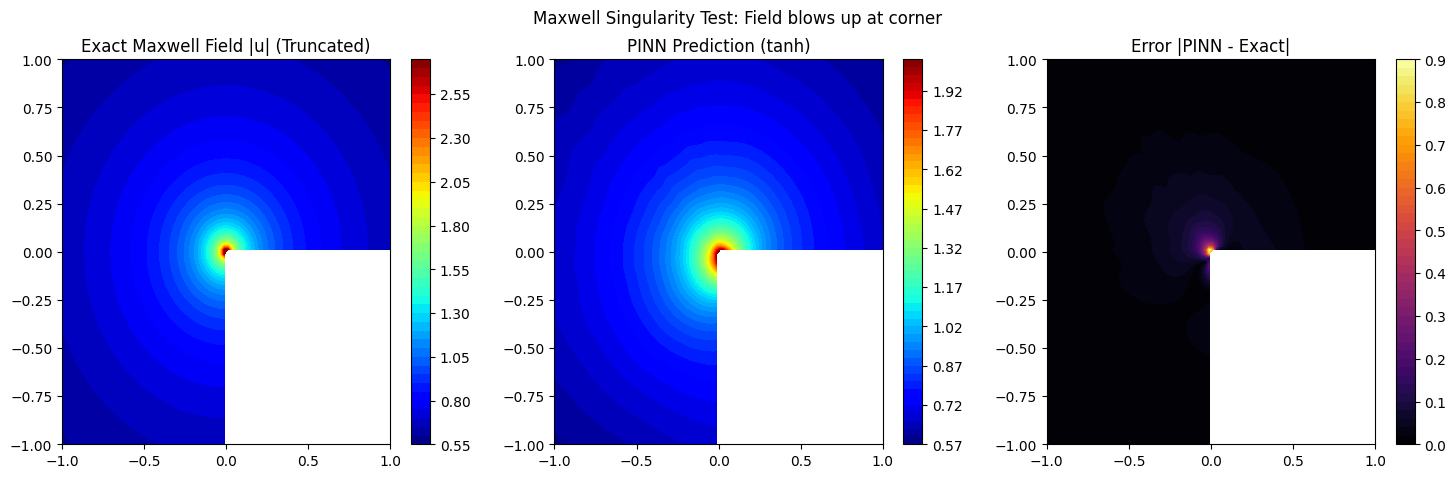

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 矢量 Maxwell 真解生成器 (Ground Truth)
# ---------------------------------------------------------
# 对应文献中的构造：u = curl(Phi), Phi = r^(2/3)sin(2/3 theta)
# 这导致 u 的分量在 r->0 时趋向无穷 (r^(-1/3))
def get_maxwell_exact(x, y):
    # 转极坐标
    r = np.sqrt(x**2 + y**2) + 1e-8 # 避免除0
    theta = np.arctan2(y, x)
    theta = np.where(theta < 0, theta + 2*np.pi, theta) # [0, 2pi]
    
    # 系数 alpha = 2/3
    alpha = 2/3.0
    
    # 标量势 Phi 的导数
    # dPhi/dr = (2/3) * r^(-1/3) * sin(2/3 theta)
    dPhi_dr = alpha * (r**(alpha - 1)) * np.sin(alpha * theta)
    
    # dPhi/dtheta = (2/3) * r^(2/3) * cos(2/3 theta)
    dPhi_dtheta = alpha * (r**alpha) * np.cos(alpha * theta)
    
    # 链式法则求 Cartesian 梯度 (dPhi/dx, dPhi/dy)
    # d/dx = cos(t) d/dr - sin(t)/r d/dt
    # d/dy = sin(t) d/dr + cos(t)/r d/dt
    
    cos_t = x / r
    sin_t = y / r
    
    dPhi_dx = cos_t * dPhi_dr - (sin_t / r) * dPhi_dtheta
    dPhi_dy = sin_t * dPhi_dr + (cos_t / r) * dPhi_dtheta
    
    # 矢量解 u = curl(Phi) = (dPhi/dy, -dPhi/dx)
    u_x = dPhi_dy
    u_y = -dPhi_dx
    
    return u_x, u_y

# PyTorch 版本用于计算 Boundary Loss
def get_maxwell_exact_torch(x_tensor):
    x = x_tensor[:, 0:1]
    y = x_tensor[:, 1:2]
    
    r = torch.sqrt(x**2 + y**2) + 1e-6
    theta = torch.atan2(y, x)
    theta = torch.where(theta < 0, theta + 2*np.pi, theta)
    
    alpha = 2/3.0
    
    dPhi_dr = alpha * (r**(alpha - 1)) * torch.sin(alpha * theta)
    dPhi_dtheta = alpha * (r**alpha) * torch.cos(alpha * theta)
    
    cos_t = x / r
    sin_t = y / r
    
    dPhi_dx = cos_t * dPhi_dr - (sin_t / r) * dPhi_dtheta
    dPhi_dy = sin_t * dPhi_dr + (cos_t / r) * dPhi_dtheta
    
    # u = (u_x, u_y)
    return torch.cat([dPhi_dy, -dPhi_dx], dim=1)

# ---------------------------------------------------------
# 2. PINN 网络模型 (输出 2维 矢量)
# ---------------------------------------------------------
class VectorPINN(nn.Module):
    def __init__(self, activation_name='tanh'):
        super().__init__()
        
        # 自定义激活函数工厂
        if activation_name == 'tanh':
            self.act = nn.Tanh()
        elif activation_name == 'relu':
            self.act = nn.ReLU()
        elif activation_name == 'rational':
            # 简单的有理函数近似
            self.act_fn = lambda x: x / (1 + torch.abs(x))
            self.act = None
        else:
            self.act = nn.Tanh()
            
        self.activation_name = activation_name
        
        self.layers = nn.Sequential(
            nn.Linear(2, 64), 
            # 这里的激活函数调用
            nn.Tanh() if self.act else nn.Identity(),
            nn.Linear(64, 64), 
            nn.Tanh() if self.act else nn.Identity(),
            nn.Linear(64, 64), 
            nn.Tanh() if self.act else nn.Identity(),
            nn.Linear(64, 2) # 输出 (u_x, u_y)
        )
        
    def forward(self, x):
        if self.activation_name == 'rational':
            h = x
            # 手动实现非 nn.Module 的激活
            for layer in self.layers:
                if isinstance(layer, nn.Linear):
                    h = layer(h)
                    if layer != self.layers[-1]: # 最后一层不激活
                        h = h / (1 + torch.abs(h))
            return h
        else:
            return self.layers(x)

# Maxwell 残差计算
def maxwell_residual(model, x_in):
    x_in.requires_grad = True
    u = model(x_in)
    u_x = u[:, 0:1]
    u_y = u[:, 1:2]
    d_uy_dx = torch.autograd.grad(u_y, x_in, torch.ones_like(u_y), create_graph=True)[0][:, 0:1]
    d_ux_dy = torch.autograd.grad(u_x, x_in, torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    
    scalar_curl = d_uy_dx - d_ux_dy
    
    # (d(curl)/dy, -d(curl)/dx)
    d_curl_dy = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0][:, 1:2]
    d_curl_dx = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0][:, 0:1]
    
    res_x = d_curl_dy 
    res_y = -d_curl_dx
    
    # div u = 0 
    d_ux_dx = torch.autograd.grad(u_x, x_in, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    d_uy_dy = torch.autograd.grad(u_y, x_in, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    res_div = d_ux_dx + d_uy_dy
    
    return res_x, res_y, res_div

# ---------------------------------------------------------
# 4. 训练流程
# ---------------------------------------------------------
# 改变这里测试不同激活函数： 'tanh', 'rational', 'relu','relu3','sin'
ACT_TYPE = 'tanh' 
class CubicReLU(nn.Module):
    def forward(self, x):
        return torch.pow(torch.relu(x), 3)

model = VectorPINN(ACT_TYPE)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# L-shape 内部点
pts = np.random.rand(4000, 2) * 2 - 1
mask = ~((pts[:, 0] > 0) & (pts[:, 1] < 0))
x_col = torch.tensor(pts[mask], dtype=torch.float32)


n1_x=torch.rand(100,1)
x_bc1=torch.cat([-n1_x,-torch.ones_like(n1_x)],dim=1)

n2_y=torch.rand(200,1)*2-1
x_bc2=torch.cat([-torch.ones_like(n2_y),n2_y],dim=1)

n3_x=torch.rand(200,1)*2-1
x_bc3=torch.cat([n3_x,torch.ones_like(n3_x)],dim=1)

n4_y=torch.rand(100,1)
x_bc4=torch.cat([torch.ones_like(n4_y),n4_y],dim=1)

n5_x=torch.rand(100,1)
x_bc5=torch.cat([n5_x,torch.zeros_like(n5_x)],dim=1)

n6_y=torch.rand(100,1)
x_bc6=torch.cat([torch.zeros_like(n6_y),-n6_y],dim=1)

x_bc=torch.cat([x_bc1,x_bc2,x_bc3,x_bc4,x_bc5,x_bc6],dim=0)


u_bc_true = get_maxwell_exact_torch(x_bc)

print(f"--- Training Maxwell PINN ({ACT_TYPE}) ---")
print("Trying to capture singularity where Field -> Infinity at (0,0)")

loss_history = []
for epoch in range(10001):
    optimizer.zero_grad()
    
    # PDE Loss: curl curl u = 0, div u = 0
    rx, ry, rdiv = maxwell_residual(model, x_col)
    loss_pde = torch.mean(rx**2 + ry**2) + torch.mean(rdiv**2)
    
    # BC Loss
    u_pred_bc = model(x_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc_true)**2)
    
    loss = loss_pde + 10 * loss_bc
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f}")


n_grid = 100
x = np.linspace(-1, 1, n_grid)
y = np.linspace(-1, 1, n_grid)
X, Y = np.meshgrid(x, y)
XY = np.stack([X.ravel(), Y.ravel()], 1)
XY_torch = torch.tensor(XY, dtype=torch.float32)

# 遮罩 L-shape 外部
geom_mask = (X > 0) & (Y < 0)

with torch.no_grad():
    U_vec = model(XY_torch).numpy()
    # 计算场强模长 |E| = sqrt(ux^2 + uy^2)
    U_mag_pred = np.sqrt(U_vec[:,0]**2 + U_vec[:,1]**2).reshape(n_grid, n_grid)

# 计算真解场强
ux_true, uy_true = get_maxwell_exact(X, Y)
U_mag_true = np.sqrt(ux_true**2 + uy_true**2)

# 处理无穷大以便绘图 (截断)
clip_val = 10.0
U_mag_true = np.clip(U_mag_true, 0, clip_val)
U_mag_pred = np.clip(U_mag_pred, 0, clip_val)

U_mag_pred[geom_mask] = np.nan
U_mag_true[geom_mask] = np.nan

# 绘图对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 真解
im0 = axes[0].contourf(X, Y, U_mag_true, levels=50, cmap='jet')
axes[0].set_title("Exact Maxwell Field |u| (Truncated)")
fig.colorbar(im0, ax=axes[0])

# PINN 预测
im1 = axes[1].contourf(X, Y, U_mag_pred, levels=50, cmap='jet')
axes[1].set_title(f"PINN Prediction ({ACT_TYPE})")
fig.colorbar(im1, ax=axes[1])

# 误差
err = np.abs(U_mag_pred - U_mag_true)
err[geom_mask] = np.nan
im2 = axes[2].contourf(X, Y, err, levels=50, cmap='inferno')
axes[2].set_title("Error |PINN - Exact|")
fig.colorbar(im2, ax=axes[2])

plt.suptitle("Maxwell Singularity Test: Field blows up at corner")
plt.show()

